In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report


## Dataset
### Contains EEG spectral features and confusion labels collected while subjects watched educational videos

In [2]:
# Load data


# df = pd.read_csv("../data/raw/confused-eeg/EEG_data.csv") #pc
df = pd.read_csv("/kaggle/input/confused-eeg/EEG_data.csv") #kaggle

df.head()


,SubjectID,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,predefinedlabel,user-definedlabeln
0,0.0,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0.0,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0.0,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0.0,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0.0,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0


In [3]:
# target variable: predefined confusion label was selected as the target variable, 
# representing whether a student was confused while watching the video.
# try user-defined label later (future work)
df['target'] = df['predefinedlabel']
df['target'].value_counts(normalize=True)


target
0.0    0.520022
1.0    0.479978
Name: proportion, dtype: float64

In [4]:
# feature selection
drop_cols = [
    'SubjectID',
    'VideoID',
    'Raw',
    'predefinedlabel',
    'user-definedlabeln'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

X = df.drop(columns='target')
y = df['target']



## EDA

Log transformation will be tried based on EDA

In [5]:
eeg_cols = [
    'Delta', 'Theta', 'Alpha1', 'Alpha2',
    'Beta1', 'Beta2', 'Gamma1', 'Gamma2'
]

for col in eeg_cols:
    X[col] = np.log1p(df[col])


In [6]:
# baseline model

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Baseline Model: Logistic Regression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred_proba)

print( "roc_auc: ", roc_auc)


roc_auc:  0.5670039461084783


roc_auc is 0.57, which could be considered weak. To improve, we can drop “Attention” and “Meditation”, since they are proprietary summary scores and often add noise


In [7]:
drop_extra = ['Attention', 'Mediation']
X = X.drop(columns=[c for c in drop_extra if c in X.columns])


In [8]:
# baseline model

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Baseline Model: Logistic Regression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred_proba)

print( "roc_auc: ", roc_auc)


roc_auc:  0.5691904683487945


Again, roc_auc omly improves slightv which is expected as this dataset would benefit more from a random forest model

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred)

print( "RF roc_auc: ", roc_auc)


RF roc_auc:  0.592571923468672


Exploratory data analysis shows that EEG spectral power features have highly right-skewed, heavy-tailed distributions spanning several orders of magnitude, which is typical for single-channel EEG recordings. Attention and Meditation metrics showed irregular distributions with large zero-value spikes, likely reflecting proprietary preprocessing or signal dropouts, and were therefore excluded. The substantial overlap between distributions across confusion states suggests that confusion is not strongly separable using univariate linear decision boundaries, motivating the use of feature transformations and non-linear models.

Now, we'll try one more model to comparerrformance: XGBoost

In [10]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [11]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [12]:
from sklearn.metrics import roc_auc_score

y_pred = xgb.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred)
print("XGBoost ROC-AUC:", roc_auc)


XGBoost ROC-AUC: 0.6057843729224989


Results are similar but it is an improvement. Now, we'll cross-validate the xgb model

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    xgb,
    X,
    y,
    scoring="roc_auc",
    cv=cv
)

print("Mean ROC-AUC:", scores.mean())
print("Std:", scores.std())


Mean ROC-AUC: 0.602409652271908
Std: 0.005137572241165928


### Feature importance

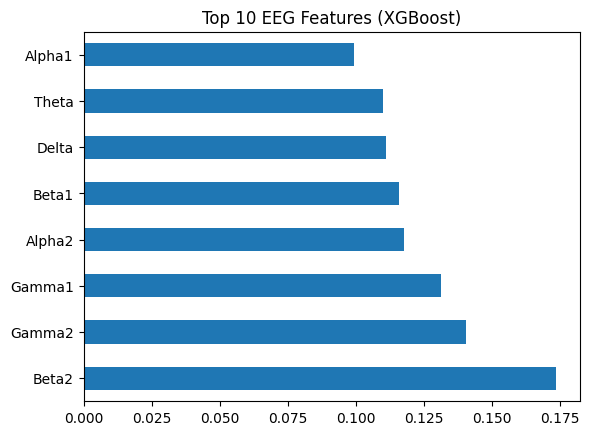

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10).plot(kind="barh")
plt.title("Top 10 EEG Features (XGBoost)")
plt.show()


Feature importance analysis shows that higher-frequency EEG bands (Beta2, Gamma1, Gamma2) contributed most strongly to confusion classification, followed by mid-frequency bands (Beta1, Alpha2). This pattern is consistent with prior findings linking beta–gamma activity to cognitive load and attentional effort.